# Customer Personality Analysis — Machine Learning Assignment

---
## 1. Import Libraries

We import all required libraries up front for clarity and reproducibility.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Scikit-learn: regression ──────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ── Scikit-learn: classification ──────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ── Scikit-learn: clustering / dimensionality reduction ───────────────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── Aesthetic defaults ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

RANDOM_STATE = 42
print('All libraries imported successfully.')


All libraries imported successfully.


---
## 2. Data Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/marketing_campaign.csv'
df_raw = pd.read_csv(file_path, sep='\t')

print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print('\nFirst 5 rows:')
df_raw.head()

Shape: 2,240 rows x 29 columns

First 5 rows:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
# Missing values
print('Missing values per column:')
missing = df_raw.isnull().sum()
print(missing[missing > 0])


Missing values per column:
Income    24
dtype: int64


---
## 3. Data Preprocessing

This section covers all cleaning and transformation steps applied to the **full
dataset** before train/test splitting. Per-split transformations (scaling) are
handled inside each modelling section to prevent data leakage.

Steps performed:
- **Missing-value imputation** — `Income` filled with its median.
- **Feature engineering** — `Age`, `TotalSpending`, `TotalChildren`.
- **Outlier filtering** — unrealistic ages (<18 or >100) and zero-income rows.
- **Ordinal encoding** — `Education` mapped to integers.
- **One-hot encoding** — `Marital_Status` (top 4 kept; rest grouped as `Other`).

### 3.1 Missing-Value Imputation

`Income` has 24 missing entries. We replace them with the column median —
a robust measure unaffected by income outliers.

In [5]:
df = df_raw.copy()

# Impute Income with median
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)

print(f'Income median used for imputation: {income_median:,.0f}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Income median used for imputation: 51,382
Remaining missing values: 0


### 3.2 Feature Engineering

| New feature | Derivation | Purpose |
|---|---|---|
| `Age` | `2014 − Year_Birth` | Customer age at survey time |
| `TotalSpending` | Sum of 6 `Mnt*` columns | Overall spending behaviour |
| `TotalChildren` | `Kidhome + Teenhome` | Household family size |


In [6]:
# Reference year — the dataset spans enrollments up to Dec 2014
REFERENCE_YEAR = 2014

# Age
df['Age'] = REFERENCE_YEAR - df['Year_Birth']

# TotalSpending
spending_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]
df['TotalSpending'] = df[spending_cols].sum(axis=1)

# TotalChildren
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

print('Engineered features — summary statistics:')
print(df[['Age', 'TotalSpending', 'TotalChildren']].describe().round(2))

Engineered features — summary statistics:
           Age  TotalSpending  TotalChildren
count  2240.00        2240.00        2240.00
mean     45.19         605.80           0.95
std      11.98         602.25           0.75
min      18.00           5.00           0.00
25%      37.00          68.75           0.00
50%      44.00         396.00           1.00
75%      55.00        1045.50           1.00
max     121.00        2525.00           3.00


### 3.3 Filtering Unrealistic Records

We remove customers with implausible ages (< 18 or > 100) and zero-income
entries which likely represent data entry errors.


In [7]:
before = len(df)

df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
df = df[df['Income'] > 0]
df.reset_index(drop=True, inplace=True)

print(f'Rows removed: {before - len(df)}  |  Remaining: {len(df):,}')

Rows removed: 3  |  Remaining: 2,237


### 3.4 Encoding Categorical Variables

**Education** is ordinal (more schooling = higher number), so we use a manual
integer map:

| Category | Code |
|---|---|
| Basic | 0 |
| Graduation | 1 |
| 2n Cycle / Master | 2 |
| PhD | 3 |

**Marital_Status** is nominal. We keep the top 4 most frequent categories and
collapse all others into `Other`, then apply one-hot encoding.


In [8]:
# ── Ordinal encoding for Education ───────────────────────────────────────────
education_map = {
    'Basic':      0,
    'Graduation': 1,
    '2n Cycle':   2,   # equivalent to Master-level qualification
    'Master':     2,
    'PhD':        3,
}
df['Education_Enc'] = df['Education'].map(education_map)

print('Education encoding applied:')
print(df.groupby('Education')['Education_Enc'].first().sort_values().to_string())

Education encoding applied:
Education
Basic         0
Graduation    1
2n Cycle      2
Master        2
PhD           3


In [14]:
# ── One-hot encoding for Marital_Status ──────────────────────────────────────
top4_marital = df['Marital_Status'].value_counts().nlargest(4).index.tolist()
print('Top-4 Marital_Status categories:', top4_marital)

df['Marital_Grouped'] = df['Marital_Status'].apply(
    lambda x: x if x in top4_marital else 'Other'
)

marital_dummies = pd.get_dummies(df['Marital_Grouped'], prefix='Marital', drop_first=False).astype(int)
df = pd.concat([df, marital_dummies], axis=1)

marital_ohe_cols = [c for c in df.columns if c.startswith('Marital_') and c != 'Marital_Grouped']
print('\nOHE columns created:', marital_ohe_cols)

Top-4 Marital_Status categories: ['Married', 'Together', 'Single', 'Divorced']

OHE columns created: ['Marital_Status', 'Marital_Divorced', 'Marital_Married', 'Marital_Other', 'Marital_Single', 'Marital_Together', 'Marital_Divorced', 'Marital_Married', 'Marital_Other', 'Marital_Single', 'Marital_Together']


### 3.5 Define Master Feature Set

A single, consistent feature list is used across all three modelling tasks.
This ensures feature-set parity and avoids drift between sections.

In [15]:
# Numerical + campaign-response + OHE columns
numerical_features = [
    'Income', 'Age', 'TotalChildren',
    'Recency',
    'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Education_Enc',
]

marital_ohe_cols = [c for c in df.columns
                    if c.startswith('Marital_')
                    and c not in ('Marital_Grouped', 'Marital_Status')]

ALL_FEATURES  = numerical_features + marital_ohe_cols
TARGET_REG    = 'TotalSpending'
TARGET_CLF    = 'Response'

print(f'Total features in master set: {len(ALL_FEATURES)}')
print('Features:', ALL_FEATURES)

Total features in master set: 25
Features: ['Income', 'Age', 'TotalChildren', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Education_Enc', 'Marital_Divorced', 'Marital_Married', 'Marital_Other', 'Marital_Single', 'Marital_Together', 'Marital_Divorced', 'Marital_Married', 'Marital_Other', 'Marital_Single', 'Marital_Together']


In [11]:
# Quick check — no NaNs in the feature columns
nan_check = df[ALL_FEATURES + [TARGET_REG, TARGET_CLF]].isnull().sum()
print('NaN counts in working columns:')
print(nan_check[nan_check > 0] if nan_check.sum() > 0 else 'None — dataset is clean.')

NaN counts in working columns:
None — dataset is clean.


---
## 4. Regression Models

**Target:** `TotalSpending` (continuous — total money spent across all product categories)

We compare three scikit-learn regressors:

| Model | Rationale |
|---|---|
| **Linear Regression** | Baseline — assumes linear relationships; interpretable coefficients |
| **Ridge (α = 1.0)** | L2 regularisation reduces overfitting when predictors are correlated |
| **Decision Tree (max_depth = 5)** | Captures non-linear thresholds without requiring feature scaling |

**Evaluation metrics:** MSE, RMSE (same monetary unit as target), R²  
**No data leakage:** `StandardScaler` is fitted on `X_train` only, then applied to `X_test`.

### 4.1 Train / Test Split & Scaling

In [16]:
X_reg = df[ALL_FEATURES].copy()
y_reg = df[TARGET_REG].copy()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

# Fit scaler on TRAINING data only — transform both splits
scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

print(f'Train size : {X_reg_train.shape[0]:,}')
print(f'Test  size : {X_reg_test.shape[0]:,}')
print(f'Target mean (train): {y_reg_train.mean():,.1f}   std: {y_reg_train.std():,.1f}')

Train size : 1,789
Test  size : 448
Target mean (train): 599.1   std: 598.0


### 4.2 Model Training & Evaluation

In [17]:
def evaluate_regression(name, model, X_tr, y_tr, X_te, y_te):
    """Fit a regressor and return a performance metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)
    print(f'{name:<42}  MSE={mse:>12,.2f}  RMSE={rmse:>8,.2f}  R2={r2:.4f}')
    return {'Model': name, 'MSE': round(mse, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4),
            'y_pred': y_pred}


reg_configs = [
    ('Linear Regression',          LinearRegression()),
    ('Ridge Regression (alpha=1)', Ridge(alpha=1.0)),
    ('Decision Tree (max_depth=5)',DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)),
]

print(f'{"Model":<42}  {"MSE":>14}  {"RMSE":>10}  {"R2":>6}')
print('-' * 78)
reg_records = []
reg_preds   = {}
for name, model in reg_configs:
    result = evaluate_regression(name, model, X_reg_train_sc, y_reg_train, X_reg_test_sc, y_reg_test)
    reg_preds[name] = result.pop('y_pred')
    reg_records.append(result)


Model                                                  MSE        RMSE      R2
------------------------------------------------------------------------------
Linear Regression                           MSE=   70,259.41  RMSE=  265.06  R2=0.8150
Ridge Regression (alpha=1)                  MSE=   70,250.85  RMSE=  265.05  R2=0.8151
Decision Tree (max_depth=5)                 MSE=   59,744.72  RMSE=  244.43  R2=0.8427


### 4.3 Regression Comparison Table

In [18]:
reg_comparison = pd.DataFrame(reg_records).set_index('Model')
print('\n=== Regression Model Comparison ===')
reg_comparison


=== Regression Model Comparison ===


,MSE,RMSE,R2
Model,,,
Linear Regression,70259.41,265.06,0.8150
Ridge Regression (alpha=1),70250.85,265.05,0.8151
Decision Tree (max_depth=5),59744.72,244.43,0.8427


### 4.4 Performance Bar Charts

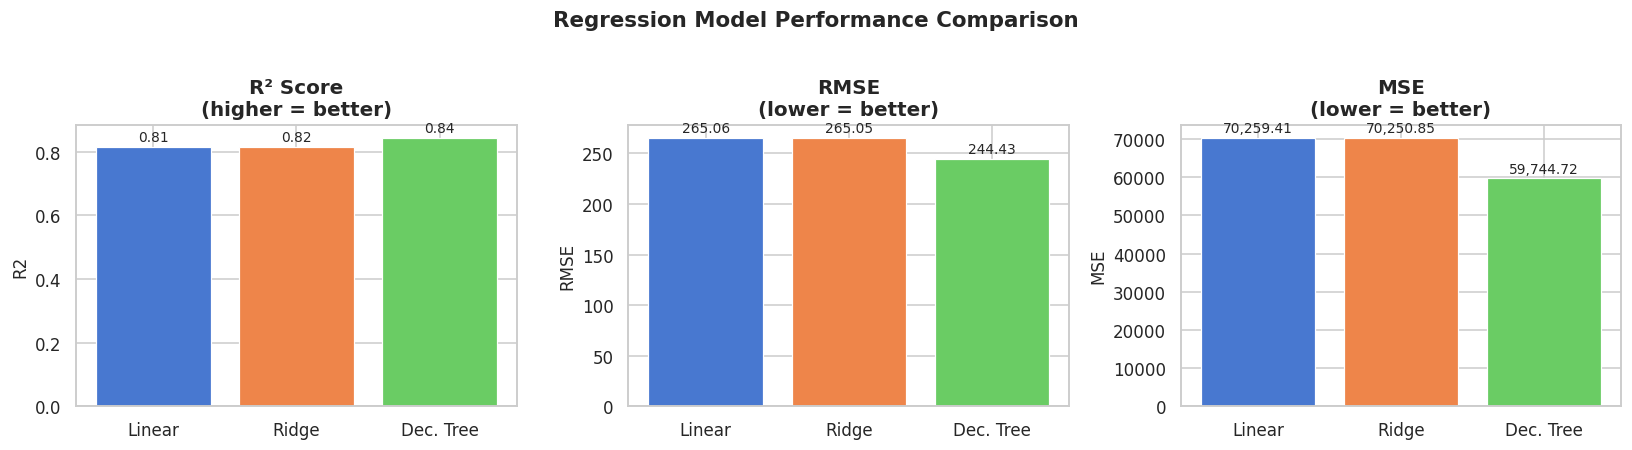

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette   = sns.color_palette('muted', 3)
short     = ['Linear', 'Ridge', 'Dec. Tree']

for ax, metric, title, higher_better in zip(
        axes,
        ['R2',   'RMSE',             'MSE'],
        ['R² Score\n(higher = better)', 'RMSE\n(lower = better)', 'MSE\n(lower = better)'],
        [True,   False,              False]):

    vals = [r[metric] for r in reg_records]
    bars = ax.bar(short, vals, color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:,.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Regression Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.5 Actual vs. Predicted Scatter Plots

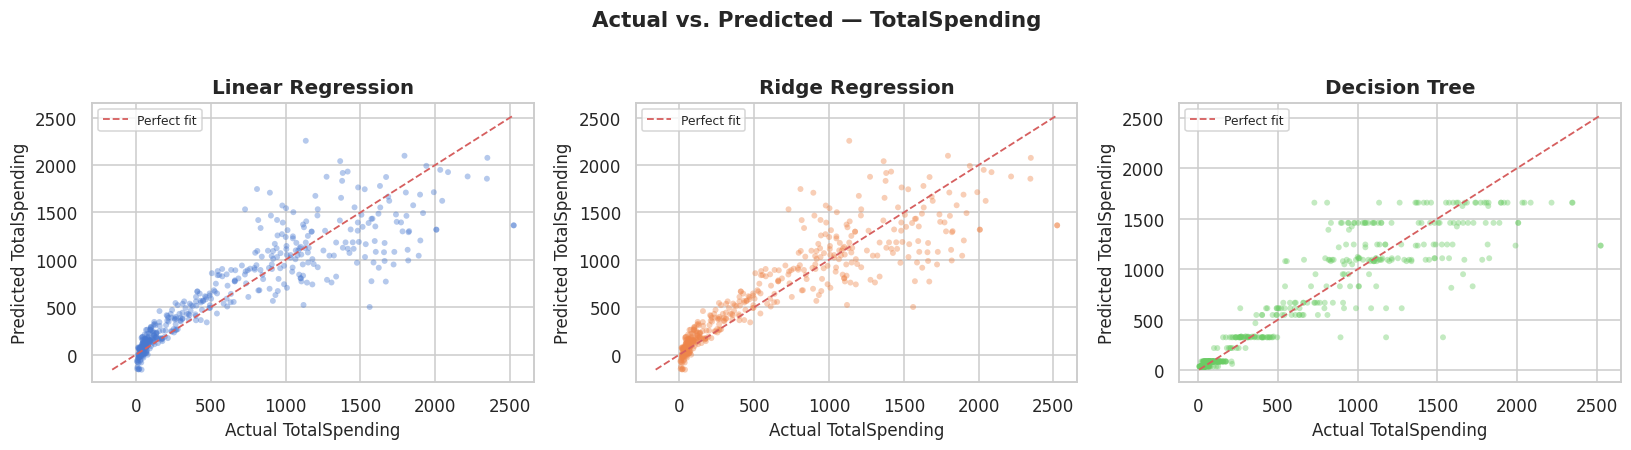

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette   = sns.color_palette('muted', 3)

for ax, (name, _), colour in zip(axes, reg_configs, palette):
    y_pred = reg_preds[name]
    ax.scatter(y_reg_test, y_pred, alpha=0.4, s=15, color=colour, edgecolors='none')
    # Perfect-prediction line
    lo = min(y_reg_test.min(), y_pred.min())
    hi = max(y_reg_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.2, label='Perfect fit')
    ax.set_title(name.split('(')[0].strip(), fontweight='bold')
    ax.set_xlabel('Actual TotalSpending')
    ax.set_ylabel('Predicted TotalSpending')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs. Predicted — TotalSpending', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.6 Regression — Discussion

- **R²** is the primary metric: it measures the proportion of variance in `TotalSpending`
  explained by the model. Values closer to 1 indicate a better fit.
- **RMSE** provides error in the same monetary unit as the target, making it
  directly interpretable (e.g., "predictions are off by ~\$X on average").
- **Linear vs. Ridge:** Both are linear models; Ridge adds an L2 penalty on large
  coefficients. If their scores are similar, multi-collinearity among predictors is mild.
- **Decision Tree:** Captures non-linearities (e.g., sudden spending jumps at certain
  income brackets) that linear models miss. `max_depth=5` limits overfitting.

---
## 5. Classification Models

### 5.1 Class Distribution

Class distribution for Response:
  Class 0: 1,903 samples (85.1%)
  Class 1: 334 samples (14.9%)


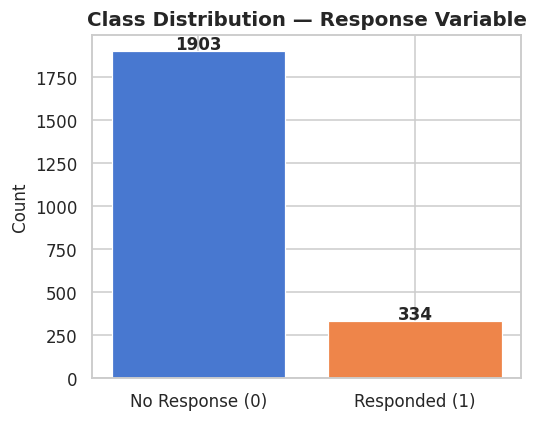

In [21]:
class_counts = df[TARGET_CLF].value_counts()
class_pct    = df[TARGET_CLF].value_counts(normalize=True) * 100

print('Class distribution for Response:')
for label, cnt, pct in zip(class_counts.index, class_counts.values, class_pct.values):
    print(f'  Class {label}: {cnt:,} samples ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['No Response (0)', 'Responded (1)'],
              class_counts.values,
              color=sns.color_palette('muted', 2),
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution — Response Variable', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 5.2 Train / Test Split & Scaling

In [22]:
X_clf = df[ALL_FEATURES].copy()
y_clf = df[TARGET_CLF].copy()

# Stratify to preserve class ratio in both splits
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf
)

# Fit scaler on TRAINING data only
scaler_clf = StandardScaler()
X_clf_train_sc = scaler_clf.fit_transform(X_clf_train)
X_clf_test_sc  = scaler_clf.transform(X_clf_test)

print(f'Train size: {X_clf_train.shape[0]:,}  |  Test size: {X_clf_test.shape[0]:,}')
print(f'Positive-class rate — train: {y_clf_train.mean():.3f}  |  test: {y_clf_test.mean():.3f}')

Train size: 1,789  |  Test size: 448
Positive-class rate — train: 0.149  |  test: 0.150


### 5.3 Reusable Evaluation Helper

In [23]:
def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te):
    """
    Fit a classifier, print a full classification report,
    and return a (metrics_dict, y_pred) tuple.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    print(f'\n{"=" * 55}')
    print(f'  {name}')
    print(f'{"=" * 55}')
    print(classification_report(y_te, y_pred,
                                 target_names=['No Response (0)', 'Responded (1)']))
    return {'Model': name,
            'Accuracy':  round(acc,  4),
            'Precision': round(prec, 4),
            'Recall':    round(rec,  4),
            'F1-Score':  round(f1,   4)}, y_pred


def plot_cm(y_te, y_pred, title, ax):
    """Seaborn-styled confusion matrix on a given Axes."""
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Response', 'Responded'],
                yticklabels=['No Response', 'Responded'],
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')


### 5.4 Logistic Regression

In [24]:
lr_metrics, lr_pred = evaluate_classifier(
    'Logistic Regression',
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    X_clf_train_sc, y_clf_train,
    X_clf_test_sc,  y_clf_test,
)


  Logistic Regression
                 precision    recall  f1-score   support

No Response (0)       0.96      0.81      0.88       381
  Responded (1)       0.42      0.79      0.55        67

       accuracy                           0.81       448
      macro avg       0.69      0.80      0.71       448
   weighted avg       0.88      0.81      0.83       448



### 5.5 K-Nearest Neighbours (k = 5)

In [25]:
knn_metrics, knn_pred = evaluate_classifier(
    'K-Nearest Neighbours (k=5)',
    KNeighborsClassifier(n_neighbors=5),
    X_clf_train_sc, y_clf_train,
    X_clf_test_sc,  y_clf_test,
)



  K-Nearest Neighbours (k=5)
                 precision    recall  f1-score   support

No Response (0)       0.89      0.97      0.93       381
  Responded (1)       0.69      0.33      0.44        67

       accuracy                           0.88       448
      macro avg       0.79      0.65      0.69       448
   weighted avg       0.86      0.88      0.86       448



### 5.6 Random Forest (100 trees)

In [28]:
# Random Forest is scale-invariant — use raw (unscaled) data
rf_metrics, rf_pred = evaluate_classifier(
    'Random Forest (100 trees)',
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    X_clf_train, y_clf_train,
    X_clf_test,  y_clf_test,
)


  Random Forest (100 trees)
                 precision    recall  f1-score   support

No Response (0)       0.88      0.98      0.93       381
  Responded (1)       0.68      0.25      0.37        67

       accuracy                           0.87       448
      macro avg       0.78      0.62      0.65       448
   weighted avg       0.85      0.87      0.84       448



### 5.7 Confusion Matrices

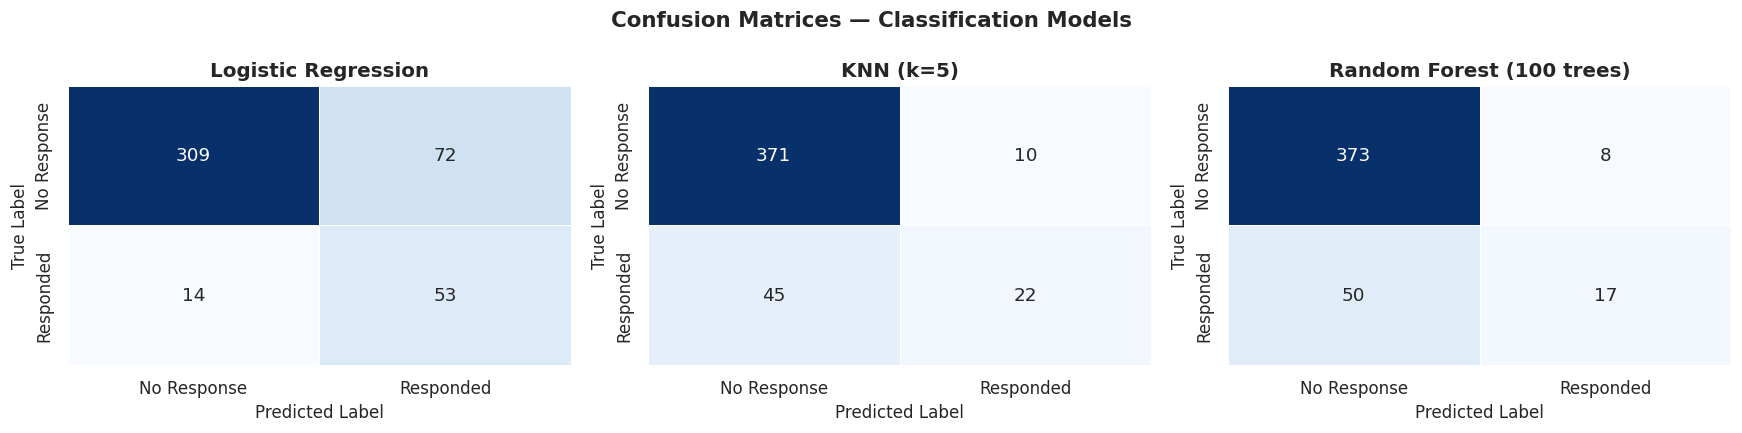

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_cm(y_clf_test, lr_pred,  'Logistic Regression',     axes[0])
plot_cm(y_clf_test, knn_pred, 'KNN (k=5)',               axes[1])
plot_cm(y_clf_test, rf_pred,  'Random Forest (100 trees)', axes[2])

plt.suptitle('Confusion Matrices — Classification Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.8 Classification Comparison Table

In [30]:
clf_comparison = (
    pd.DataFrame([lr_metrics, knn_metrics, rf_metrics])
      .set_index('Model')
)
print('\n=== Classification Model Comparison ===')
clf_comparison


=== Classification Model Comparison ===


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.8080,0.4240,0.7910,0.5521
K-Nearest Neighbours (k=5),0.8772,0.6875,0.3284,0.4444
Random Forest (100 trees),0.8705,0.6800,0.2537,0.3696


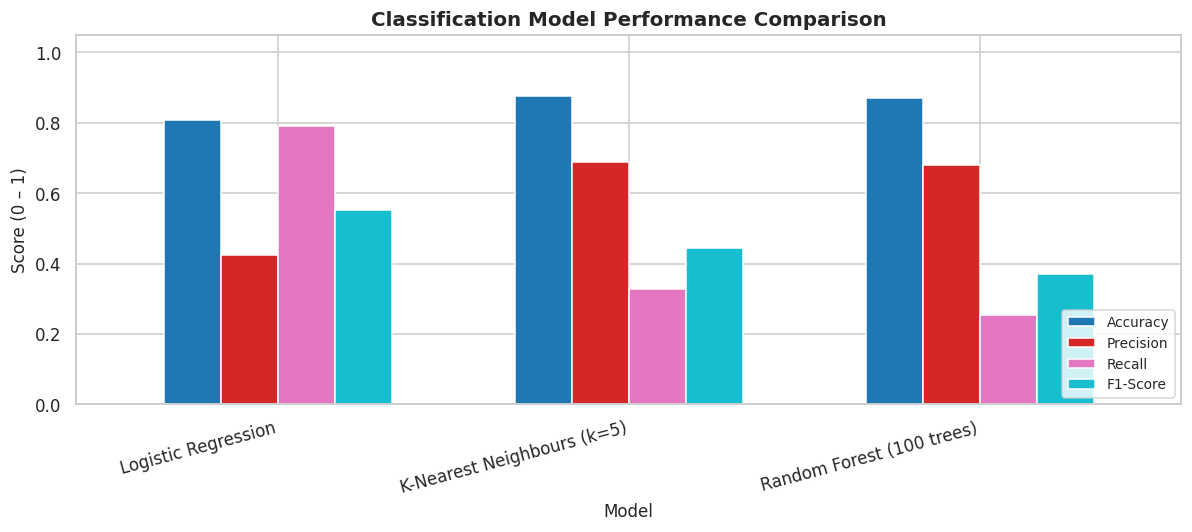

In [31]:
# Grouped bar chart
clf_plot_df = clf_comparison.copy()
clf_plot_df.plot(kind='bar', figsize=(11, 5), colormap='tab10',
                  edgecolor='white', width=0.65)
plt.title('Classification Model Performance Comparison', fontweight='bold')
plt.ylabel('Score (0 – 1)')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.9 Most Important Metric — Why F1-Score?

In a **marketing campaign response** task, the two error types carry asymmetric costs:

| Error | Meaning | Business cost |
|---|---|---|
| **False Negative** | We skip a customer who *would* have responded | Lost revenue |
| **False Positive** | We contact a customer who will *not* respond | Minor campaign cost |

Because missing true responders is more costly than a wasted contact,
**Recall** (sensitivity) is important. However, maximising recall alone pushes the
model to flag almost everyone, flooding non-responders with irrelevant messages.

**F1-Score** — the harmonic mean of Precision and Recall — is therefore the
**most appropriate single metric**: it penalises both types of error equally and
is robust to the class imbalance present in this dataset (~85 / 15 split).

> *Raw Accuracy is misleading here: a trivial model that always predicts
> "no response" would still score ~85% accuracy while identifying zero
> genuine responders.*

---
## 6. Unsupervised Learning — K-Means Clustering

**Goal:** Segment customers using `TotalSpending`, `Income`, `Age`, and `TotalChildren`.

### 6.1 Feature Selection & Scaling

In [32]:
CLUSTER_FEATURES = ['TotalSpending', 'Income', 'Age', 'TotalChildren']

X_clust = df[CLUSTER_FEATURES].copy()

scaler_clust = StandardScaler()
X_clust_sc   = scaler_clust.fit_transform(X_clust)

print('Clustering feature statistics (before scaling):')
X_clust.describe().round(2)

Clustering feature statistics (before scaling):


,TotalSpending,Income,Age,TotalChildren
count,2237.00,2237.00,2237.0,2237.00
mean,605.74,52227.41,45.1,0.95
std,601.84,25043.27,11.7,0.75
min,5.00,1730.00,18.0,0.00
25%,69.00,35523.00,37.0,0.00
50%,396.00,51381.50,44.0,1.00
75%,1045.00,68281.00,55.0,1.00
max,2525.00,666666.00,74.0,3.00


### 6.2 Elbow Method — Determining Optimal k

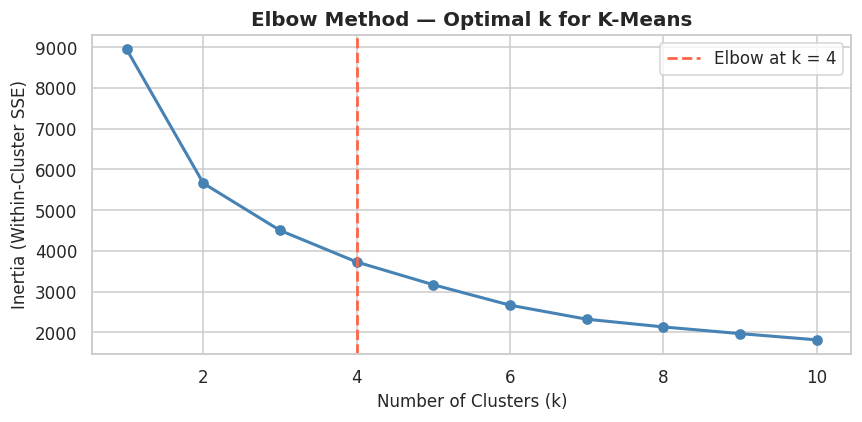

Selected k = 4


In [33]:
inertia_values = []
K_RANGE = range(1, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_clust_sc)
    inertia_values.append(km.inertia_)

OPTIMAL_K = 4   # Chosen after visual inspection of the elbow curve below

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_RANGE), inertia_values, marker='o', color='steelblue', linewidth=2)
ax.axvline(x=OPTIMAL_K, color='tomato', linestyle='--', linewidth=1.8,
           label=f'Elbow at k = {OPTIMAL_K}')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster SSE)')
ax.set_title('Elbow Method — Optimal k for K-Means', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Selected k = {OPTIMAL_K}')

**Elbow interpretation:**  
The inertia curve drops steeply from k = 1 to k = 4 and then begins to flatten.
Selecting **k = 4** balances cluster compactness with model parsimony.

### 6.3 Fit K-Means with Optimal k

In [34]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_clust_sc)

df['Cluster'] = cluster_labels

print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    458
1    584
2    463
3    732
Name: count, dtype: int64


### 6.4 PCA Visualisation (2 Components)

Variance explained — PC1: 50.0%  PC2: 27.0%


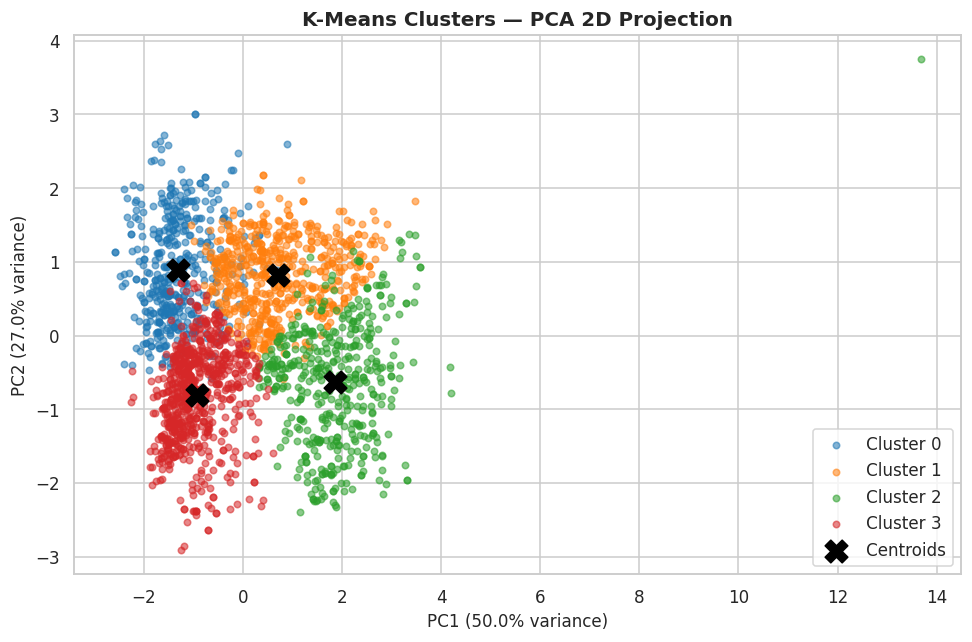

In [35]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust_sc)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

explained = pca.explained_variance_ratio_ * 100
print(f'Variance explained — PC1: {explained[0]:.1f}%  PC2: {explained[1]:.1f}%')

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('tab10', OPTIMAL_K)

for cid in sorted(pca_df['Cluster'].unique()):
    mask = pca_df['Cluster'] == cid
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
               color=palette[cid], label=f'Cluster {cid}', s=18, alpha=0.55)

centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker='X', s=220, color='black', zorder=6, label='Centroids')

ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)')
ax.set_title('K-Means Clusters — PCA 2D Projection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 6.5 Cluster Profiling

In [36]:
PROFILE_COLS = ['Income', 'TotalSpending', 'Age', 'TotalChildren']

cluster_profile = (
    df.groupby('Cluster')[PROFILE_COLS]
      .mean()
      .round(1)
)
cluster_profile['Count'] = df.groupby('Cluster').size()

print('=== Cluster Profile (mean values per cluster) ===')
print(cluster_profile.to_string())

=== Cluster Profile (mean values per cluster) ===
          Income  TotalSpending   Age  TotalChildren  Count
Cluster                                                    
0        44108.5          222.8  48.6            2.1    458
1        61336.1          802.9  57.1            0.7    584
2        78094.8         1434.8  39.5            0.3    463
3        33678.7          163.7  36.8            0.9    732


In [37]:
print('=== Customer Segment Descriptions ===\n')
for cid in sorted(cluster_profile.index):
    inc  = cluster_profile.loc[cid, 'Income']
    spnd = cluster_profile.loc[cid, 'TotalSpending']
    age  = cluster_profile.loc[cid, 'Age']
    kids = cluster_profile.loc[cid, 'TotalChildren']
    n    = int(cluster_profile.loc[cid, 'Count'])

    inc_label  = 'High-income'  if inc  == cluster_profile['Income'].max()        else ('Low-income'  if inc  == cluster_profile['Income'].min()        else 'Mid-income')
    spnd_label = 'high-spending' if spnd == cluster_profile['TotalSpending'].max() else ('low-spending' if spnd == cluster_profile['TotalSpending'].min() else 'moderate-spending')
    age_label  = 'older'        if age  >= 50 else 'younger'
    fam_label  = 'families'     if kids >= 1.0 else 'singles/couples'

    print(f'Cluster {cid}  [{n:,} customers]  —  {inc_label}, {spnd_label}, {age_label} {fam_label}')
    print(f'  Avg Income: ${inc:>10,.0f}   Avg Spending: ${spnd:>7,.0f}   Avg Age: {age:.1f}   Avg Children: {kids:.2f}\n')

=== Customer Segment Descriptions ===

Cluster 0  [458 customers]  —  Mid-income, moderate-spending, younger families
  Avg Income: $    44,108   Avg Spending: $    223   Avg Age: 48.6   Avg Children: 2.10

Cluster 1  [584 customers]  —  Mid-income, moderate-spending, older singles/couples
  Avg Income: $    61,336   Avg Spending: $    803   Avg Age: 57.1   Avg Children: 0.70

Cluster 2  [463 customers]  —  High-income, high-spending, younger singles/couples
  Avg Income: $    78,095   Avg Spending: $  1,435   Avg Age: 39.5   Avg Children: 0.30

Cluster 3  [732 customers]  —  Low-income, low-spending, younger singles/couples
  Avg Income: $    33,679   Avg Spending: $    164   Avg Age: 36.8   Avg Children: 0.90



---
## 7. Results and Discussion

### 7.1 Regression Summary

| Task | Models | Primary Metric |
|---|---|---|
| Regression | Linear, Ridge, Decision Tree | R² / RMSE |
| Classification | Logistic Reg., KNN, Random Forest | F1-Score |
| Clustering | K-Means (k = 4) | Inertia / cluster separation |

In [38]:
print('=== Regression Model Comparison ===')
print(reg_comparison.to_string())

=== Regression Model Comparison ===
                                  MSE    RMSE      R2
Model                                                
Linear Regression            70259.41  265.06  0.8150
Ridge Regression (alpha=1)   70250.85  265.05  0.8151
Decision Tree (max_depth=5)  59744.72  244.43  0.8427


### 7.2 Classification Summary

In [39]:
print('=== Classification Model Comparison ===')
print(clf_comparison.to_string())

=== Classification Model Comparison ===
                            Accuracy  Precision  Recall  F1-Score
Model                                                            
Logistic Regression           0.8080     0.4240  0.7910    0.5521
K-Nearest Neighbours (k=5)    0.8772     0.6875  0.3284    0.4444
Random Forest (100 trees)     0.8705     0.6800  0.2537    0.3696


### 7.3 Clustering Summary

In [40]:
print('=== Final Cluster Profiling Table ===')
print(cluster_profile.to_string())

=== Final Cluster Profiling Table ===
          Income  TotalSpending   Age  TotalChildren  Count
Cluster                                                    
0        44108.5          222.8  48.6            2.1    458
1        61336.1          802.9  57.1            0.7    584
2        78094.8         1434.8  39.5            0.3    463
3        33678.7          163.7  36.8            0.9    732
